# Loss vs NTK eigenvalues for a single replica

For one chosen replica, overlays on a **twin axis**:

- **Left axis** &mdash; the training (solid) and validation (dashed) loss vs epoch,
  from `loss_function_grid` (the recomputed losses the report's loss page uses).
- **Right axis** &mdash; the first `N_EIG` **NTK eigenvalues** (one curve per rank,
  1 = largest) vs epoch, from `eigenvalue_grid`.

Loss and eigenvalues live on different scales/units, hence the twin axis. Both
trajectories run over **all stored epochs** (a dense curve): the NTK eigenvalues come
from the disk-cached ensemble, while the loss is recomputed by rebuilding the model and
predicting at every stored epoch, so the first run can take a few minutes.

In [1]:
%matplotlib inline
from IPython.display import display

# Importing the API first sets KERAS_BACKEND=jax (via ntkpdf/__init__.py).
from ntkpdf.api import API
from ntkpdf.plotting.style import make_figure, draw_line, HandlerSpec, LineHandler, OKABE_ITO
from colibri.ntk.ntkutils import NTKStats

import logging
logging.basicConfig(level=logging.INFO)

Applying NTKPDF plotting style...
Using Keras backend


In [9]:
# --- Edit these ---------------------------------------------------------
FIT = "260622-ac-03-ntk-sgd"        # fit id
REPLICA = 3                          # 1-based replica id
N_EIG = 8                            # number of top NTK eigenvalues to overlay
XSCALE = "linear"
# ------------------------------------------------------------------------

# Minimal data/theory context the FK chain behind loss_function_grid needs.
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)

In [10]:
# Loss trajectories (training, validation) and the NTK eigenvalue trajectories.
tr_grid, vl_grid = API.loss_function_grid(fit=FIT, **common_dict)
eig_grid = API.eigenvalue_grid(fit=FIT, **common_dict, name="nn")
print("loss epochs:", len(tr_grid.epochs), "| eig epochs:", len(eig_grid.epochs),
      "| n_eigenvalues:", eig_grid.n_ranks)

/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


loss epochs: 401 | eig epochs: 401 | n_eigenvalues: 700


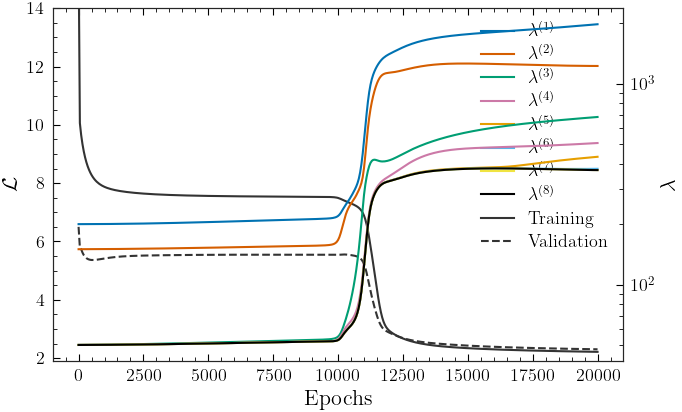

In [13]:
# Twin axis: left = loss, right = NTK eigenvalues. Both log scale.
fig, ax = make_figure()
ax_r = ax.twinx()
handles, labels = [], []

# Right axis: first N_EIG eigenvalues (one colour per rank), single replica.
for k in range(1, N_EIG + 1):
    stats = eig_grid.get_plotting_data(rank_index=k)                 # (nreplicas, n_epochs)
    one = NTKStats(stats.data[[REPLICA - 1]])                        # single replica
    h = draw_line(ax_r, one, eig_grid.xgrid, color=OKABE_ITO[k - 1], linestyle="-")
    handles.append(h)
    labels.append(eig_grid.get_plotting_label(k))

# Left axis: this replica's training (solid) and validation (dashed) loss, grey.
tr_stats = tr_grid.get_plotting_data(replica_idx=REPLICA - 1)
vl_stats = vl_grid.get_plotting_data(replica_idx=REPLICA - 1)
draw_line(ax, tr_stats, tr_grid.xgrid, color="0.2", linestyle="-")
draw_line(ax, vl_stats, vl_grid.xgrid, color="0.2", linestyle="--")
handles += [HandlerSpec("0.2", None, "-", draw_box=False),
            HandlerSpec("0.2", None, "--", draw_box=False)]
labels += [r"$\rm Training$", r"$\rm Validation$"]

ax.set_xscale(XSCALE)
# ax.set_yscale("log")
ax.set_ylim(1.9, 14)
ax_r.set_yscale("log")
ax.set_xlabel(tr_grid.xlabel)
ax.set_ylabel(r"$\mathcal{L}$")
ax_r.set_ylabel(r"$\lambda$")
# ax.set_title(rf"$\rm Replica\ {REPLICA}$")
ax.legend(handles=handles, labels=labels, handler_map={HandlerSpec: LineHandler()})
display(fig)
fig.savefig("figs/loss_eigenvalues.pdf", bbox_inches="tight", dpi=300)